In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("cleaned_ds_final_forver.csv", low_memory=False)

# Nettoyage des virgules françaises → décimales
for col in ['CAPITAL_ASSURE', 'PRIME_NETTE']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.').astype(float)

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Wilayas uniques : {df['WILAYA'].nunique()}")
print(f"   Communes uniques : {df['COMMUNE'].nunique()}")

# =============================================================================
# 1. ENCODAGE (inclut COMMUNE)
# =============================================================================
le_wilaya  = LabelEncoder()
le_commune = LabelEncoder()
le_type    = LabelEncoder()
le_zone    = LabelEncoder()

df['WILAYA_ENC']  = le_wilaya.fit_transform(df['WILAYA'])
df['COMMUNE_ENC'] = le_commune.fit_transform(df['COMMUNE'])
df['TYPE_ENC']    = le_type.fit_transform(df['TYPE'].fillna('INCONNU'))
df['ZONE_ENC']    = le_zone.fit_transform(df['ZONE_RPA'].fillna('INCONNU'))

print("✅ Encodage terminé (COMMUNE_ENC ajouté)")

# =============================================================================
# 2. CRÉATION DU LABEL "RISQUE ÉLEVÉ"
# =============================================================================
zone_medians = df.groupby('ZONE_RPA')['PRIME_NETTE'].transform('median')
df['LABEL'] = (
    (df['COEFF_A'] >= 0.15) & 
    (df['PRIME_NETTE'] < zone_medians)
).astype(int)

print(f"   Risques détectés (LABEL=1) : {df['LABEL'].sum():,} ({df['LABEL'].mean():.1%})")

# =============================================================================
# 3. MODÈLE XGBoost (avec Commune)
# =============================================================================
features = ['WILAYA_ENC', 'COMMUNE_ENC', 'TYPE_ENC']
X = df[features]
y = df['LABEL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Gestion du déséquilibre
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / max(pos, 1)

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    tree_method='hist'
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Prédictions sur tout le dataset
df['PREDICTED_LABEL'] = model.predict(X)
df['RISK_SCORE']      = model.predict_proba(X)[:, 1]

print("\n📊 Classification Report (Test set) :")
print(classification_report(y_test, model.predict(X_test), zero_division=0))



✅ Dataset chargé : 116,811 lignes × 11 colonnes
   Wilayas uniques : 55
   Communes uniques : 909
✅ Encodage terminé (COMMUNE_ENC ajouté)
   Risques détectés (LABEL=1) : 31,018 (26.6%)

📊 Classification Report (Test set) :
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     17159
           1       0.60      0.98      0.74      6204

    accuracy                           0.82     23363
   macro avg       0.79      0.87      0.80     23363
weighted avg       0.89      0.82      0.83     23363



In [24]:
df['COEFF_A'].unique()

array([0.3 , 0.12, 0.2 , 0.25, 0.  ])

In [3]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 1. Préparation des "Paniers de Risque"
# On transforme chaque ligne en une liste de caractéristiques textuelles
def build_risk_basket(row):
    return [
        f"WILAYA={row['WILAYA']}",
        f"ZONE={row['ZONE_RPA']}",
        f"TYPE={row['TYPE']}",
        f"COEFF={row['COEFF_A']}",
        f"RISQUE={'ELEVE' if row['PREDICTED_LABEL'] == 1 else 'NORMAL'}",
        f"CONCENTRATION={'HAUTE' if row['CAPITAL_ASSURE'] > df['CAPITAL_ASSURE'].median() else 'BASSE'}"
    ]

transactions = df.apply(build_risk_basket, axis=1).tolist()

# 2. Encodage Transactionnel
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

# 3. Extraction des Itemsets Fréquents (Support min 5%)
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)

# 4. Génération des Implications (Focus sur le Risque Elevé)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# On filtre pour voir ce qui "mène" au Risque Élevé
risk_implications = rules[rules['consequents'].apply(lambda x: 'RISQUE=ELEVE' in x)]
risk_implications = risk_implications.sort_values(by='lift', ascending=False)

print("🔍 Implications stratégiques extraites :")
print(risk_implications[['antecedents', 'confidence', 'lift']].head(10))

🔍 Implications stratégiques extraites :
                                            antecedents  confidence      lift
1520         (CONCENTRATION=BASSE, TYPE=nan, COEFF=0.2)    0.498821  7.898574
1945          (ZONE=IIa, CONCENTRATION=BASSE, TYPE=nan)    0.498821  7.898574
2101          (ZONE=IIa, CONCENTRATION=BASSE, TYPE=nan)    0.498821  7.898574
2108         (CONCENTRATION=BASSE, TYPE=nan, COEFF=0.2)    0.498821  7.898574
2089  (ZONE=IIa, CONCENTRATION=BASSE, TYPE=nan, COEF...    0.498821  7.898574
1683         (CONCENTRATION=BASSE, COEFF=0.3, TYPE=nan)    1.000000  7.782212
1687          (ZONE=III, CONCENTRATION=BASSE, TYPE=nan)    1.000000  7.782212
2092  (CONCENTRATION=BASSE, WILAYA=SETIF, TYPE=nan, ...    1.000000  7.208331
1516      (CONCENTRATION=BASSE, WILAYA=SETIF, TYPE=nan)    1.000000  7.208331
2085  (ZONE=IIa, CONCENTRATION=BASSE, WILAYA=SETIF, ...    1.000000  7.208331


In [4]:

from sklearn.metrics import classification_report
from catboost import CatBoostClassifier

# 1. Préparation et Nettoyage des données
# On remplit les valeurs manquantes pour les catégories
df['TYPE'] = df['TYPE'].fillna('INCONNU')
df['COMMUNE'] = df['COMMUNE'].fillna('INCONNU')

# On s'assure que toutes les colonnes catégorielles sont bien des chaînes de caractères (string)
cat_features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA']
for col in cat_features:
    df[col] = df[col].astype(str)

# 2. Définition des variables
features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA', 'COEFF_A']
X = df[features]
y = df['LABEL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Configuration et Entraînement de CatBoost
# auto_class_weights='Balanced' va aider pour le déséquilibre (0.74/0.26)
model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    auto_class_weights='Balanced',
    verbose=100,
    eval_metric='F1'
)

model_cat.fit(X_train, y_train, eval_set=(X_test, y_test))

# 4. Évaluation
y_pred = model_cat.predict(X_test)
print("\nClassification Report (CatBoost - Corrigé):")
print(classification_report(y_test, y_pred))

# Ajout du score au dataframe
df['RISK_SCORE_CAT'] = model_cat.predict_proba(X)[:, 1]

0:	learn: 0.8840360	test: 0.8831170	best: 0.8831170 (0)	total: 253ms	remaining: 2m 6s
100:	learn: 0.8839956	test: 0.8831170	best: 0.8831170 (0)	total: 8.58s	remaining: 33.9s
200:	learn: 0.8841845	test: 0.8843575	best: 0.8843575 (168)	total: 16.5s	remaining: 24.6s
300:	learn: 0.8842607	test: 0.8843575	best: 0.8843575 (168)	total: 24.8s	remaining: 16.4s
400:	learn: 0.8842761	test: 0.8843575	best: 0.8843575 (168)	total: 34.3s	remaining: 8.48s
499:	learn: 0.8844329	test: 0.8843575	best: 0.8843575 (168)	total: 42.7s	remaining: 0us

bestTest = 0.8843575348
bestIteration = 168

Shrink model to first 169 iterations.

Classification Report (CatBoost - Corrigé):
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     17159
           1       0.60      0.98      0.74      6204

    accuracy                           0.82     23363
   macro avg       0.79      0.87      0.80     23363
weighted avg       0.89      0.82      0.83     23363



In [15]:
df['TYPE'] = df['TYPE'].fillna('INCONNU')
df['COMMUNE'] = df['COMMUNE'].fillna('INCONNU')

# AMÉLIORATION : Création de variables métier
# 1. Ratio d'exposition relative (Capital par rapport à la moyenne)
mean_cap = df['CAPITAL_ASSURE'].mean()
df['CAP_RELATIVE'] = df['CAPITAL_ASSURE'] / mean_cap

# 2. Score de Dangerosité Combiné (Zone RPA + Coeff A)
# On transforme la zone en numérique pour le calcul
zone_map = {'0': 0, 'I': 1, 'IIa': 2, 'IIb': 3, 'III': 4}
df['ZONE_NUM'] = df['ZONE_RPA'].map(zone_map).fillna(0)
df['DANGER_INDEX'] = df['ZONE_NUM'] * df['COEFF_A']

# --- 2. Définition des variables (Features) ---
# Ajout de CAPITAL_ASSURE et des nouvelles variables créées
cat_features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA']
features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA', 'COEFF_A', 'CAPITAL_ASSURE', 'CAP_RELATIVE', 'DANGER_INDEX']

for col in cat_features:
    df[col] = df[col].astype(str)

X = df[features]
y = df['LABEL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Entraînement CatBoost Optimisé ---
model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,        # Plus lent pour plus de précision
    depth=8,                   # Un peu plus profond pour capturer les interactions
    l2_leaf_reg=5,             # Régularisation contre le sur-apprentissage
    cat_features=cat_features,
    auto_class_weights='Balanced', # Gère le déséquilibre des classes
    early_stopping_rounds=50,  # S'arrête si le score n'augmente plus sur le test
    eval_metric='F1',
    verbose=100
)

model_cat.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# --- 4. Évaluation ---
y_pred = model_cat.predict(X_test)
print("\n🚀 RAPPORT DE CLASSIFICATION AMÉLIORÉ :")
print(classification_report(y_test, y_pred))

# --- 5. Export pour le Dashboard ---
# On sauvegarde le modèle pour l'utiliser avec Streamlit 
model_cat.save_model("model_sismique_final.cbm")
print("\n✅ Modèle sauvegardé sous 'model_sismique_final.cbm'")

# Ajout du score final au dataframe pour analyse
df['RISK_SCORE_FINAL'] = model_cat.predict_proba(X)[:, 1]


from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# On définit la stratégie de découpage (5 plis)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# On utilise cross_val_score
# Note : CatBoost a besoin de cat_features, on utilise donc un petit wrapper ou on le fait manuellement
scores = []

print("🧪 Lancement de la Validation Croisée...")

for train_index, test_index in skf.split(X, y):
    # Découpage des données
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Entraînement rapide pour le test
    model_cv = CatBoostClassifier(iterations=200, logging_level='Silent', cat_features=cat_features)
    model_cv.fit(X_train_cv, y_train_cv)
    
    # Score F1
    score = model_cv.score(X_test_cv, y_test_cv)
    scores.append(score)

print(f"✅ Scores par pli : {scores}")
print(f"📊 Moyenne des scores : {np.mean(scores):.4f}")
print(f"📉 Écart-type (Stabilité) : {np.std(scores):.4f}")

if np.std(scores) < 0.05:
    print("🚀 Résultat : Le modèle est stable !")
else:
    print("⚠️ Résultat : Le modèle est instable, attention aux données.")

0:	learn: 0.9423722	test: 0.9471617	best: 0.9471617 (0)	total: 125ms	remaining: 2m 4s
100:	learn: 0.9542028	test: 0.9569499	best: 0.9573498 (89)	total: 18s	remaining: 2m 40s
200:	learn: 0.9566589	test: 0.9579858	best: 0.9580998 (173)	total: 38.9s	remaining: 2m 34s
300:	learn: 0.9575680	test: 0.9588407	best: 0.9588407 (299)	total: 56.5s	remaining: 2m 11s
400:	learn: 0.9584736	test: 0.9588694	best: 0.9590683 (350)	total: 1m 13s	remaining: 1m 49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9590682625
bestIteration = 350

Shrink model to first 351 iterations.

🚀 RAPPORT DE CLASSIFICATION AMÉLIORÉ :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17159
           1       0.94      0.94      0.94      6204

    accuracy                           0.97     23363
   macro avg       0.96      0.96      0.96     23363
weighted avg       0.97      0.97      0.97     23363


✅ Modèle sauvegardé sous 'model_sismique_final

In [16]:
def test_robustesse(model_a_tester):
    # Création de cas extrêmes
    cas_tests = pd.DataFrame({
        'WILAYA': ['MARS_CITY', 'ADRAR', 'ALGER'], # MARS_CITY n'existe pas
        'COMMUNE': ['INCONNUE_XYZ', 'ADRAR', 'EL HARRACH'],
        'TYPE': ['INDUSTRIELLE', 'HABITATION', 'INDUSTRIELLE'],
        'ZONE_RPA': ['III', '0', 'III'],
        'COEFF_A': [0.50, 0.05, 0.30], # 0.50 est énorme
        'CAPITAL_ASSURE': [999999999999, 0, 50000000], # Très gros, Zéro, Normal
        'CAP_RELATIVE': [1000.0, 0.0, 1.0],
        'DANGER_INDEX': [2.0, 0.0, 1.2]
    })
    
    # Assurer le format string
    for col in cat_features:
        cas_tests[col] = cas_tests[col].astype(str)
        
    # Prédictions
    probs = model_a_tester.predict_proba(cas_tests)[:, 1]
    
    print("🔬 RÉSULTATS DU STRESS TEST :")
    print(f"1. Ville inconnue + Capital Géant : Score Risque = {probs[0]:.2%}")
    print(f"2. Capital à Zéro + Zone 0 : Score Risque = {probs[1]:.2%}")
    print(f"3. Cas Normal (Alger) : Score Risque = {probs[2]:.2%}")

test_robustesse(model_cat)

🔬 RÉSULTATS DU STRESS TEST :
1. Ville inconnue + Capital Géant : Score Risque = 31.04%
2. Capital à Zéro + Zone 0 : Score Risque = 0.32%
3. Cas Normal (Alger) : Score Risque = 14.62%


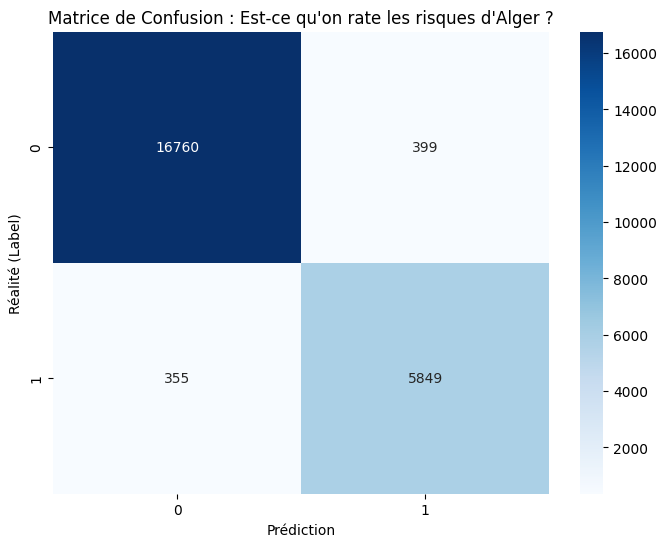

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité (Label)')
plt.title('Matrice de Confusion : Est-ce qu\'on rate les risques d\'Alger ?')
plt.show()

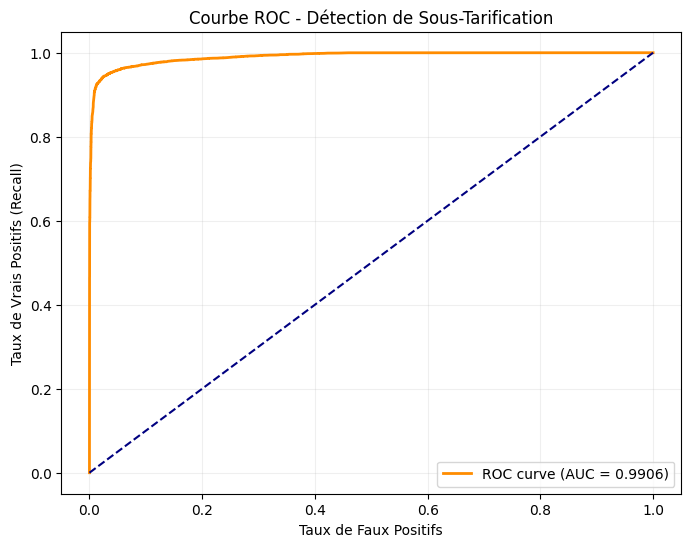

✅ Analyse terminée. AUC : 0.9906


In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Définition des colonnes que le modèle a appris à utiliser (les versions ENCODÉES)
features_model = ['WILAYA_ENC', 'COMMUNE_ENC', 'TYPE_ENC', 'CAPITAL_ASSURE']

# 2. On prépare le X_test en allant chercher ces colonnes dans le DataFrame d'origine 'df'
# On utilise l'index de X_test pour garder les mêmes lignes que votre découpage actuel
X_test_numeric = df.loc[X_test.index, features_model]

# 3. Calcul des probabilités de risque (Classe 1)
y_probs = model.predict_proba(X_test_numeric)[:, 1]

# 4. Calcul et affichage ROC/AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], color='navy', linestyle='--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC - Détection de Sous-Tarification')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

print(f"✅ Analyse terminée. AUC : {roc_auc:.4f}")

In [6]:
import pandas as pd
import numpy as np

# 1. Sélection aléatoire de 20 indices dans le set de test
random_indices = np.random.choice(X_test.index, size=20, replace=False)

# 2. Préparation des données pour la prédiction (uniquement les colonnes encodées)
features_model = ['WILAYA_ENC', 'COMMUNE_ENC', 'TYPE_ENC', 'CAPITAL_ASSURE']
X_test_samples = df.loc[random_indices, features_model]

# 3. Prédiction
probs = model.predict_proba(X_test_samples)[:, 1]
preds = model.predict(X_test_samples)

# 4. Création du tableau de synthèse lisible
test_reels = df.loc[random_indices, ['WILAYA', 'COMMUNE', 'ZONE_RPA', 'PRIME_NETTE', 'COEFF_A']].copy()
test_reels['RISQUE_REEL'] = y_test.loc[random_indices].values
test_reels['PRED_MODELE'] = preds
test_reels['SCORE_RISQUE'] = (probs * 100).round(2)

# 5. Ajout d'un indicateur de succès
test_reels['RESULTAT'] = test_reels.apply(
    lambda x: "✅" if x['RISQUE_REEL'] == x['PRED_MODELE'] else "❌", axis=1
)

print("🧪 TEST ALÉATOIRE SUR 20 DOSSIERS D'ASSURANCE")
print("=" * 110)
print(test_reels.to_string(index=False))
print("=" * 110)

# Calcul du taux de réussite sur cet échantillon
succes = (test_reels['RESULTAT'] == "✅").sum()
print(f"🎯 Précision sur cet échantillon : {succes}/20 ({(succes/20)*100}%)")

🧪 TEST ALÉATOIRE SUR 20 DOSSIERS D'ASSURANCE
            WILAYA            COMMUNE ZONE_RPA  PRIME_NETTE  COEFF_A  RISQUE_REEL  PRED_MODELE  SCORE_RISQUE RESULTAT
BORDJ BOU ARRERIDJ BORDJ BOU ARRERIDJ        I      2500.00     0.12            0            0      0.010000        ✅
             ALGER           HARRAOUA      III      1500.00     0.30            1            1     99.540001        ✅
             ALGER         EUCALYPTUS      III      2500.00     0.30            0            0      1.790000        ✅
             BLIDA        OUED ALLEUG      III      2500.00     0.30            0            0      2.220000        ✅
BORDJ BOU ARRERIDJ BORDJ BOU ARRERIDJ        I      1500.00     0.12            0            0      0.210000        ✅
              ORAN               ORAN      IIa      2500.00     0.20            0            0      3.350000        ✅
            SKIKDA             SKIKDA      IIa      2340.00     0.20            0            0     24.850000        ✅
           

# CDC

**1-Concentration**

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SÉCURISATION ET CALCUL ---
# On définit les colonnes vraiment nécessaires
cols_disponibles = df.columns.tolist()

# Nettoyage sécurisé des colonnes numériques existantes
for col in ['CAPITAL_ASSURE', 'PRIME_NETTE', 'COEFF_A']:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col].str.replace(',', '.'), errors='coerce')

# Gestion de la Sévérité (Valeur par défaut 0.4 si absente)
if 'SEVERITE' not in df.columns:
    print("ℹ️ Colonne 'SEVERITE' absente, utilisation de la valeur standard 0.4")
    df['SEVERITE'] = 0.4

# Recalcul du PML si nécessaire
if 'PML' not in df.columns or df['PML'].isnull().all():
    df['PML'] = df['CAPITAL_ASSURE'] * df['COEFF_A'] * df['SEVERITE']

# --- 2. ANALYSE D'EXPOSITION (Finalité : Mesurer l'adéquation) ---
exposure_summary = df.groupby('ZONE_RPA').agg(
    Nombre_Contrats=('PRIME_NETTE', 'count'),
    Capital_Expose=('CAPITAL_ASSURE', 'sum'),
    PML_Total=('PML', 'sum'),
    Primes_Totatles=('PRIME_NETTE', 'sum')
).reset_index()

# Ratio de couverture : Prime collectée par rapport au risque pris (PML)
exposure_summary['Ratio_Securite'] = (exposure_summary['Primes_Totatles'] / exposure_summary['PML_Total']) * 100
# Poids du risque dans le portefeuille total
total_pml = exposure_summary['PML_Total'].sum()
exposure_summary['Part_Risque_%'] = (exposure_summary['PML_Total'] / total_pml) * 100

# --- 3. IDENTIFICATION CONCENTRATION (Finalité : Zones d'assainissement) ---
def identifier_zone(row):
    if row['Part_Risque_%'] > 35:
        return "🔥 SURCONCENTRATION (Action : Réduire l'exposition)"
    elif row['Part_Risque_%'] < 10:
        return "❄️ SOUS-CONCENTRATION (Action : Développement commercial)"
    else:
        return "⚖️ ÉQUILIBRÉ"

exposure_summary['Strategie'] = exposure_summary.apply(identifier_zone, axis=1)

print("📋 SYNTHÈSE STRATÉGIQUE DU PORTEFEUILLE")
print("=" * 100)
print(exposure_summary.to_string(index=False))
print("=" * 100)

# --- 4. TOP 10 COMMUNES À ASSAINIR ---
# (Où la perte maximale possible est la plus élevée)
top_risques = df.groupby(['WILAYA', 'COMMUNE'])['PML'].sum().reset_index()
top_risques = top_risques.sort_values('PML', ascending=False).head(10)

print("\n📍 TOP 10 DES POINTS DE CONCENTRATION (COMMUNES) :")
print(top_risques.to_string(index=False))

ℹ️ Colonne 'SEVERITE' absente, utilisation de la valeur standard 0.4
📋 SYNTHÈSE STRATÉGIQUE DU PORTEFEUILLE
ZONE_RPA  Nombre_Contrats  Capital_Expose    PML_Total  Primes_Totatles  Ratio_Securite  Part_Risque_%                                                 Strategie
       0              518    5.517798e+09 0.000000e+00     2.107844e+06             inf       0.000000 ❄️ SOUS-CONCENTRATION (Action : Développement commercial)
       I            46478    2.657513e+11 1.275606e+10     1.248380e+08        0.978656      17.933237                                              ⚖️ ÉQUILIBRÉ
     III            37632    3.027587e+11 3.633104e+10     1.768558e+08        0.486790      51.076365        🔥 SURCONCENTRATION (Action : Réduire l'exposition)
     IIa            31593    2.607490e+11 2.085992e+10     1.059926e+08        0.508116      29.326134                                              ⚖️ ÉQUILIBRÉ
     IIb              590    1.183804e+10 1.183804e+09     4.545514e+06        0.383975

In [13]:
# 1. Préparation de la donnée de test (Scénario spécifique)
# Note : Le capital assuré n'est pas dans vos 'features' d'entraînement, 
# donc sa valeur n'influencera pas directement la prédiction du modèle ici.
scenario_data = pd.DataFrame({
    'WILAYA': ['SETIF'],
    'COMMUNE': ['EL EULMA'],
    'TYPE': ['INDUSTRIELLE'],
  
    'ZONE_RPA': ['III'],
    'COEFF_A': [0.4]  # Valeur par défaut pour Zone IIa / Usage Industriel
})

# 2. Conversion en string (pour correspondre au format d'entraînement)
for col in cat_features:
    scenario_data[col] = scenario_data[col].astype(str)

# 3. Prédiction
probabilite = model_cat.predict_proba(scenario_data)[0][1]
classe = model_cat.predict(scenario_data)[0]

# 4. Affichage du résultat
print(f"📊 RÉSULTAT DU SCÉNARIO (Mascara - Industrielle - Zone IIa) :")
print(f"---")
print(f"Probabilité de risque élevé (Classe 1) : {probabilite:.2%}")
print(f"Verdict : {'⚠️ RISQUE ÉLEVÉ' if classe == 1 else '✅ RISQUE MODÉRÉ'}")

📊 RÉSULTAT DU SCÉNARIO (Mascara - Industrielle - Zone IIa) :
---
Probabilité de risque élevé (Classe 1) : 15.80%
Verdict : ✅ RISQUE MODÉRÉ


In [12]:
# Dans votre notebook
model_cat.save_model("model_sismique_catboost.cbm")

0:	learn: 0.9423722	test: 0.9471617	best: 0.9471617 (0)	total: 123ms	remaining: 2m 2s
100:	learn: 0.9542028	test: 0.9569499	best: 0.9573498 (89)	total: 22.9s	remaining: 3m 23s
200:	learn: 0.9566589	test: 0.9579858	best: 0.9580998 (173)	total: 46.7s	remaining: 3m 5s
300:	learn: 0.9575680	test: 0.9588407	best: 0.9588407 (299)	total: 1m 5s	remaining: 2m 31s
400:	learn: 0.9584736	test: 0.9588694	best: 0.9590683 (350)	total: 1m 24s	remaining: 2m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9590682625
bestIteration = 350

Shrink model to first 351 iterations.

🧪 VALIDATION CROISÉE (5-FOLD)...
✅ Stabilité (Moyenne +/- Écart-type): 0.9695 (+/- 0.0006)

💾 Modèle sauvegardé : 'model_sismique_final.cbm'

📋 TOP 10 DES RISQUES IDENTIFIÉS (NORMALISÉS) :
       WILAYA  COMMUNE  CAPITAL_ASSURE ZONE_RPA  RISK_INDEX  \
66287  TIPAZA  HADJOUT        385320.0      III       100.0   
44544  TIPAZA  HADJOUT        364800.0      III       100.0   
41923  TIPAZA  HADJOUT        34200

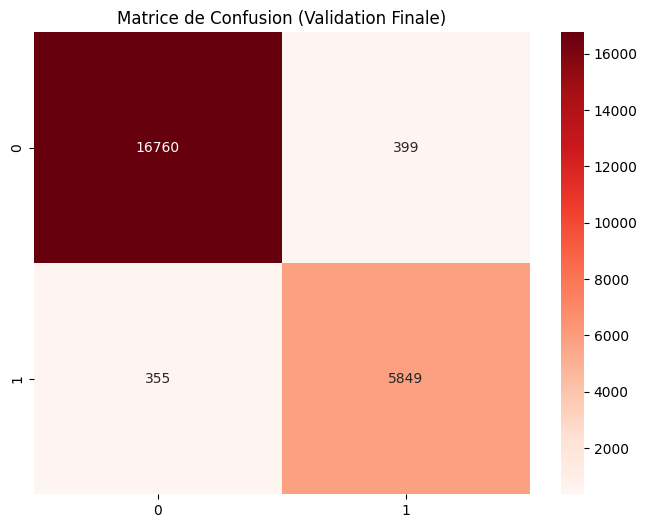

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PRÉPARATION ET FEATURE ENGINEERING
# ==========================================
# Gestion des valeurs manquantes
df['TYPE'] = df['TYPE'].fillna('INCONNU')
df['COMMUNE'] = df['COMMUNE'].fillna('INCONNU')

# A. Normalisation du Capital (Log) pour éviter que les gros montants n'écrasent tout
df['CAPITAL_LOG'] = np.log1p(df['CAPITAL_ASSURE'])

# B. Création du Danger Index (Poids exponentiel sur la zone RPA)
zone_map = {'0': 0, 'I': 1, 'IIa': 2, 'IIb': 3, 'III': 4}
df['ZONE_NUM'] = df['ZONE_RPA'].map(zone_map).fillna(0)
df['DANGER_INDEX'] = (df['ZONE_NUM'] ** 2) * df['COEFF_A']

# C. Ratio d'exposition relative
df['CAP_RELATIVE'] = df['CAPITAL_ASSURE'] / df['CAPITAL_ASSURE'].mean()

# ==========================================
# 2. CONFIGURATION DES VARIABLES
# ==========================================
cat_features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA']
features = ['WILAYA', 'COMMUNE', 'TYPE', 'ZONE_RPA', 'COEFF_A', 
            'CAPITAL_LOG', 'CAP_RELATIVE', 'DANGER_INDEX']

# Conversion forcée en string pour CatBoost
for col in cat_features:
    df[col] = df[col].astype(str)

X = df[features]
y = df['LABEL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. ENTRAÎNEMENT DU MODÈLE OPTIMISÉ
# ==========================================
model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    cat_features=cat_features,
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    eval_metric='F1',
    verbose=100
)

model_cat.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# ==========================================
# 4. VALIDATION CROISÉE (STABILITÉ)
# ==========================================
print("\n🧪 VALIDATION CROISÉE (5-FOLD)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx] 
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
    
    tmp_model = CatBoostClassifier(iterations=200, logging_level='Silent', cat_features=cat_features)
    tmp_model.fit(X_train_cv, y_train_cv)
    cv_scores.append(tmp_model.score(X_test_cv, y_test_cv))

print(f"✅ Stabilité (Moyenne +/- Écart-type): {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

# ==========================================
# 5. NORMALISATION ET RISK INDEX (POUR LA DIRECTION)
# ==========================================
# Calcul des scores sur tout le dataset
df['RISK_PROBA'] = model_cat.predict_proba(X)[:, 1]

# Normalisation de 0 à 100
df['RISK_INDEX'] = (df['RISK_PROBA'] / df['RISK_PROBA'].max()) * 100

def categoriser(score):
    if score >= 80: return "🔴 CRITIQUE (Assainissement immédiat)"
    if score >= 50: return "🟠 ÉLEVÉ (Surveillance)"
    if score >= 20: return "🟡 MODÉRÉ"
    return "🟢 FAIBLE"

df['DECISION_STRATEGIQUE'] = df['RISK_INDEX'].apply(categoriser)

# ==========================================
# 6. SAUVEGARDE ET EXPORT
# ==========================================
model_cat.save_model("model_sismique_final.cbm")
print("\n💾 Modèle sauvegardé : 'model_sismique_final.cbm'")

# Affichage du Top 10 des risques identifiés
print("\n📋 TOP 10 DES RISQUES IDENTIFIÉS (NORMALISÉS) :")
cols_view = ['WILAYA', 'COMMUNE', 'CAPITAL_ASSURE', 'ZONE_RPA', 'RISK_INDEX', 'DECISION_STRATEGIQUE']
print(df[cols_view].sort_values(by='RISK_INDEX', ascending=False).head(10))

# Matrice de confusion pour valider la précision
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, model_cat.predict(X_test)), annot=True, fmt='d', cmap='Reds')
plt.title("Matrice de Confusion (Validation Finale)")
plt.show()

In [19]:
from sklearn.metrics import classification_report

# Prédictions sur le jeu de test
y_pred = model_cat.predict(X_test)

print("\n📊 MÉTRIQUES DE PERFORMANCE DÉTAILLÉES :")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Risque Faible (0)', 'Risque Élevé (1)']))
print("-" * 60)


📊 MÉTRIQUES DE PERFORMANCE DÉTAILLÉES :
------------------------------------------------------------
                   precision    recall  f1-score   support

Risque Faible (0)       0.98      0.98      0.98     17159
 Risque Élevé (1)       0.94      0.94      0.94      6204

         accuracy                           0.97     23363
        macro avg       0.96      0.96      0.96     23363
     weighted avg       0.97      0.97      0.97     23363

------------------------------------------------------------


In [20]:
# ==========================================
# SAUVEGARDE DU MODÈLE ET DES MÉTADONNÉES
# ==========================================

# 1. Sauvegarde du modèle au format binaire CatBoost (le plus rapide et léger)
model_cat.save_model("model_sismique_final.cbm")

# 2. Sauvegarde au format JSON (optionnel, utile pour voir les paramètres en clair)
model_cat.save_model("model_sismique_final.json", format="json")

# 3. Sauvegarde des colonnes de features pour être sûr de garder le même ordre dans le dashboard
import joblib
joblib.dump(features, 'features_list.pkl')

print("✅ Modèle sauvegardé avec succès sous le nom : 'model_sismique_final.cbm'")
print("✅ Liste des variables sauvegardée sous le nom : 'features_list.pkl'")

✅ Modèle sauvegardé avec succès sous le nom : 'model_sismique_final.cbm'
✅ Liste des variables sauvegardée sous le nom : 'features_list.pkl'
